# Train EfficientNet-B0 Severity Scoring Model

Fine-tunes EfficientNet-B0 to predict severity scores (1-10) from images.
Uses transfer learning with frozen early layers.

## Imports

In [1]:
import json
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


## Configuration

In [2]:
# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Image size: (224, 224)
Batch size: 32
Epochs: 10
Learning rate: 0.001


## Create Severity Model Architecture

In [3]:
def create_severity_model() -> Model:
    """
    Create EfficientNet-B0 based severity regression model.

    Returns:
        Keras model that outputs severity score (1-10)
    """
    # Load pre-trained EfficientNet-B0
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    # Freeze early layers (keep last 20 trainable)
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    # Add regression head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    # Output: sigmoid * 9 + 1 to constrain to 1-10 range
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model

print("Creating model...")
model = create_severity_model()

# Count trainable/non-trainable parameters
trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_count = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

print(f"\nModel created successfully!")
print(f"Total parameters: {trainable_count + non_trainable_count:,}")
print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters: {non_trainable_count:,}")

Creating model...

Model created successfully!
Total parameters: 4,394,020.0
Trainable parameters: 1,695,409
Non-trainable parameters: 2,698,611.0


In [4]:
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,394,020 (16.76 MB)

 Trainable params: 1,695,409 (6.47 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

## Create Synthetic Dataset

In [5]:
def create_synthetic_dataset(data_path: Path, num_samples: int = 500):
    """
    Create synthetic image dataset for training.

    Since we don't have labeled images, we create synthetic samples
    using the existing classification model predictions.

    Args:
        data_path: Path to severity training data JSON
        num_samples: Number of synthetic samples to generate

    Returns:
        Tuple of (X_train, y_train, X_val, y_val)
    """
    # Load severity labels
    with open(data_path, "r") as f:
        severity_data = json.load(f)

    # Map issue types to class indices (from our trained classifier)
    type_to_features = {
        "POTHOLE": 0,
        "GARBAGE": 1,
        "ILLEGAL_PARKING": 2,
        "DAMAGED_SIGN": 3,
        "FALLEN_TREE": 4,
        "VANDALISM": 5,
        "DEAD_ANIMAL": 6,
        "DAMAGED_CONCRETE": 7,
        "DAMAGED_ELECTRICAL": 8,
    }

    # Generate synthetic images (noise + class-specific patterns)
    np.random.seed(42)
    X = []
    y = []

    for sample in severity_data[:num_samples]:
        issue_type = sample["issue_type"]
        severity = sample["severity"]
        type_idx = type_to_features.get(issue_type, 0)

        # Create synthetic image with class-specific patterns
        img = np.random.rand(224, 224, 3) * 0.3  # Base noise

        # Add class-specific color patterns
        if issue_type in ["POTHOLE", "DAMAGED_CONCRETE"]:
            # Gray/brown tones for road damage
            img[:, :, 0] += 0.3  # Red channel
            img[:, :, 1] += 0.2  # Green channel
        elif issue_type == "GARBAGE":
            # Mixed colors for garbage
            img[::2, ::2, :] += 0.4  # Patchy pattern
        elif issue_type == "FALLEN_TREE":
            # Green/brown for vegetation
            img[:, :, 1] += 0.4  # Green channel
        elif issue_type == "DAMAGED_ELECTRICAL":
            # Dark with highlights for electrical
            img *= 0.5
            img[100:124, :, :] += 0.3  # Horizontal line pattern
        elif issue_type == "DEAD_ANIMAL":
            # Dark with some color
            img *= 0.6
            img[80:144, 80:144, 0] += 0.3  # Central blob

        # Add severity-based intensity variation
        intensity_factor = 0.5 + (severity / 10) * 0.5
        img *= intensity_factor

        img = np.clip(img, 0, 1)
        X.append(img)
        y.append((severity - 1) / 9)  # Normalize to 0-1 for sigmoid

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    # Split into train/val
    split_idx = int(len(X) * 0.8)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    return X_train, y_train, X_val, y_val

In [6]:
models_dir = Path("../models")
data_path = models_dir / "severity_training_data.json"

# Check if training data exists
if not data_path.exists():
    print("Training data not found. Please run generate_severity_data.ipynb first!")
else:
    print("Preparing dataset...")
    X_train, y_train, X_val, y_val = create_synthetic_dataset(data_path, num_samples=1000)

    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Image shape: {X_train[0].shape}")
    print(f"Label range: [{y_train.min():.3f}, {y_train.max():.3f}]")

Preparing dataset...
Training samples: 800
Validation samples: 200
Image shape: (224, 224, 3)
Label range: [0.022, 1.000]


## Visualize Sample Images

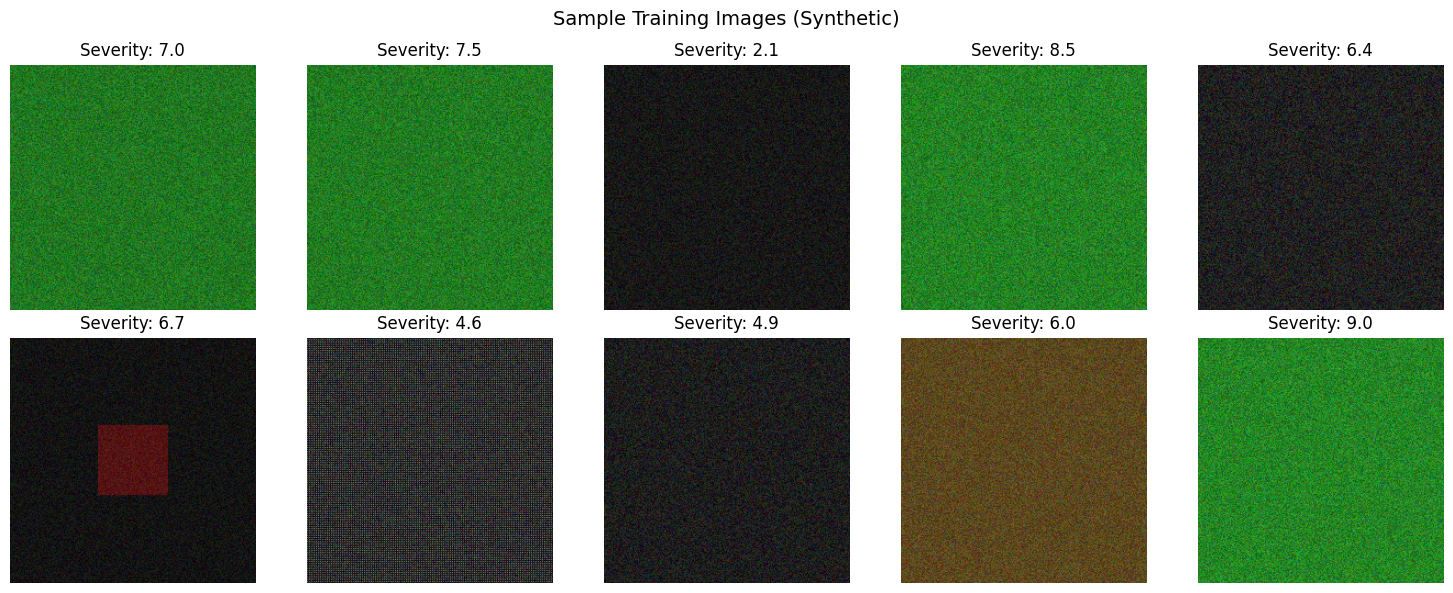

In [7]:
# Visualize some training samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_train[i * 80])  # Sample every 80th image
    severity_actual = y_train[i * 80] * 9 + 1  # Convert back to 1-10
    axes[i].set_title(f'Severity: {severity_actual:.1f}')
    axes[i].axis('off')

plt.suptitle('Sample Training Images (Synthetic)', fontsize=14)
plt.tight_layout()
plt.show()

## Compile and Train Model

In [8]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

print("Model compiled!")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: Mean Squared Error")
print(f"  Metrics: Mean Absolute Error")

Model compiled!
  Optimizer: Adam (lr=0.001)
  Loss: Mean Squared Error
  Metrics: Mean Absolute Error


In [9]:
# Callbacks
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

checkpoint = ModelCheckpoint(
    str(models_dir / "severity_model.keras"),
    monitor="val_mae",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_mae",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks configured:")
print("  - ModelCheckpoint (save best model)")
print("  - EarlyStopping (patience=5)")

Callbacks configured:
  - ModelCheckpoint (save best model)
  - EarlyStopping (patience=5)


In [10]:
print("Training model...")
print("="*50)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print("\nTraining complete!")

Training model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0650 - mae: 0.2089
Epoch 1: val_mae improved from None to 0.21074, saving model to ../models/severity_model.keras

Epoch 1: finished saving model to ../models/severity_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 215ms/step - loss: 0.0682 - mae: 0.2156 - val_loss: 0.0630 - val_mae: 0.2107
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0690 - mae: 0.2210
Epoch 2: val_mae improved from 0.21074 to 0.21052, saving model to ../models/severity_model.keras

Epoch 2: finished saving model to ../models/severity_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - loss: 0.0636 - mae: 0.2106 - val_loss: 0.0628 - val_mae: 0.2105
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0635 - mae: 0.2091
Epoch 3: val_mae improved from 0.21052 to 0.20770, saving model to ../models/severity_model.keras

Epoch 3: finished saving model to ../models/severity_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/

## Visualize Training History

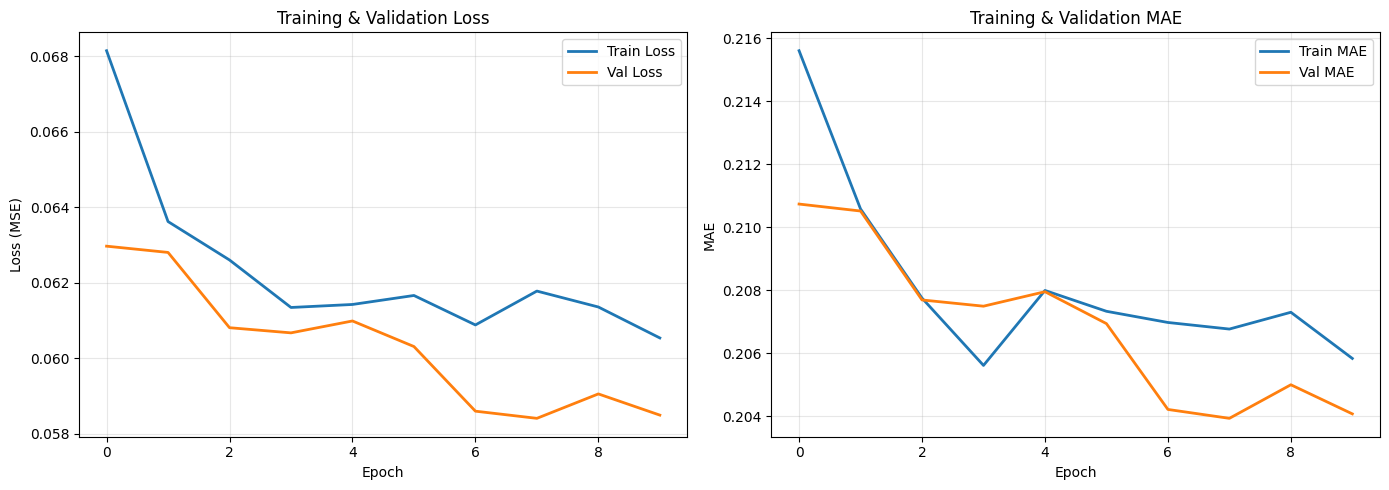

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training & Validation MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate Model

In [12]:
# Evaluate on validation set
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

# Convert MAE from normalized (0-1) to severity scale (1-10)
val_mae_scaled = val_mae * 9

print("="*50)
print("EVALUATION METRICS")
print("="*50)
print(f"Validation Loss (MSE): {val_loss:.4f}")
print(f"Validation MAE (normalized): {val_mae:.4f}")
print(f"Validation MAE (1-10 scale): {val_mae_scaled:.2f}")
print("="*50)
print(f"\nInterpretation: Model predicts severity within ±{val_mae_scaled:.1f} points on average")

EVALUATION METRICS
Validation Loss (MSE): 0.0584
Validation MAE (normalized): 0.2039
Validation MAE (1-10 scale): 1.84

Interpretation: Model predicts severity within ±1.8 points on average


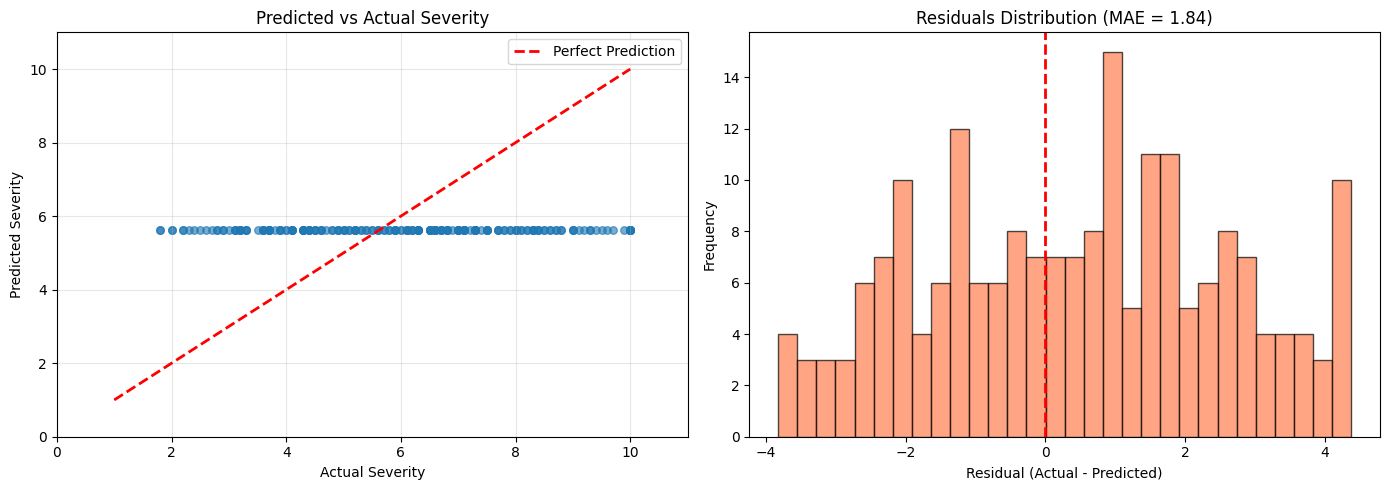

In [13]:
# Visualize predictions vs actual
y_pred = model.predict(X_val, verbose=0).flatten()

# Convert back to 1-10 scale
y_val_scaled = y_val * 9 + 1
y_pred_scaled = y_pred * 9 + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_val_scaled, y_pred_scaled, alpha=0.6, s=30)
axes[0].plot([1, 10], [1, 10], 'r--', label='Perfect Prediction', linewidth=2)
axes[0].set_xlabel('Actual Severity')
axes[0].set_ylabel('Predicted Severity')
axes[0].set_title('Predicted vs Actual Severity')
axes[0].legend()
axes[0].set_xlim(0, 11)
axes[0].set_ylim(0, 11)
axes[0].grid(True, alpha=0.3)

# Residuals histogram
residuals = y_val_scaled - y_pred_scaled
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution (MAE = {val_mae_scaled:.2f})')

plt.tight_layout()
plt.show()

## Save Model and Metrics

In [14]:
# Save final model
model.save(str(models_dir / "severity_model.keras"))
print(f"Model saved to: {models_dir / 'severity_model.keras'}")

# Save metrics
metrics = {
    "val_loss": float(val_loss),
    "val_mae": float(val_mae),
    "val_mae_scaled": float(val_mae_scaled),
    "epochs_trained": len(history.history["loss"]),
    "training_samples": len(X_train),
    "validation_samples": len(X_val),
}

with open(models_dir / "severity_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to: {models_dir / 'severity_metrics.json'}")

Model saved to: ../models/severity_model.keras
Metrics saved to: ../models/severity_metrics.json


## Test Inference

Sample Prediction Test


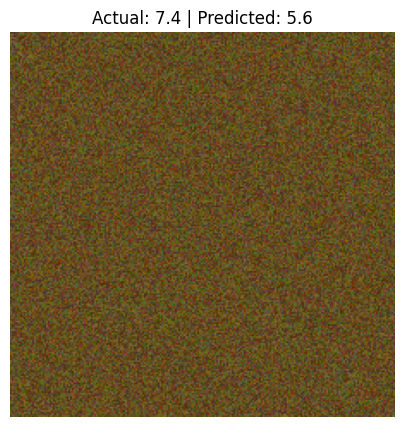

Actual Severity: 7.4
Predicted Severity: 5.6
Error: 1.78


In [15]:
# Test prediction on a sample image
sample_idx = 42
sample_img = X_val[sample_idx:sample_idx+1]
sample_actual = y_val[sample_idx] * 9 + 1

prediction = model.predict(sample_img, verbose=0)[0][0]
predicted_severity = prediction * 9 + 1

print("Sample Prediction Test")
print("="*50)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(sample_img[0])
ax.set_title(f'Actual: {sample_actual:.1f} | Predicted: {predicted_severity:.1f}')
ax.axis('off')
plt.show()

print(f"Actual Severity: {sample_actual:.1f}")
print(f"Predicted Severity: {predicted_severity:.1f}")
print(f"Error: {abs(sample_actual - predicted_severity):.2f}")